In [1]:
import numpy as np
import pandas as pd

# Preprocessing & model selection
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics & evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)

def evaluate_model(model, X, y, label="Validation"):
    preds = model.predict(X)
    acc  = accuracy_score(y, preds)
    f1   = f1_score(y, preds, average="macro")
    print(f"✅ {label} Accuracy: {acc:.4f} | Macro-F1: {f1:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y, preds))
    print("\nClassification report:")
    print(classification_report(y, preds, digits=4))
    return acc, f1


In [2]:
# DATA PREPARATION
#Reproducibility & Environment Setup
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Global seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display environment
print("✅ Environment ready")
print("Working directory:", os.getcwd())
print("Files here:", os.listdir())


✅ Environment ready
Working directory: /Users/mercedes/Desktop/Assignment2025 
Files here: ['Test-data-2025-2.xlsx', '.DS_Store', 'run.ipynb', 'fig2_validation_comparison.png', 'Training-data-2025.xlsx', 'fig3_cv_stability.png', 'Predict_1.xlsx', 'DeclarationOfOriginality_v1.1.docx', 'Predict_2.xlsx', 'fig4_confusion_matrix_dt.png', '.ipynb_checkpoints', '.jupyter', 'fig1_class_distribution.png', '~$Training-data-2025.xlsx', '~$Assignment-feature-description-2025.xlsx', 'Test-data-2025-1.xlsx']


In [3]:
#Load Dataset
file_path = "Training-data-2025.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

print("Shape before preprocessing:", df.shape)
print("Columns:", df.columns.tolist())


Shape before preprocessing: (145854, 44)
Columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [4]:
#Irrelevant Attributes
irrelevant = ["attack_cat", "stcpb", "dtcpb"]
present = [c for c in irrelevant if c in df.columns]

if present:
    df.drop(columns=present, inplace=True)
    print(f"Dropped irrelevant attributes: {present}")
else:
    print("No irrelevant attributes present in this dataset.")

print("Shape after dropping irrelevants:", df.shape)


Dropped irrelevant attributes: ['attack_cat', 'stcpb', 'dtcpb']
Shape after dropping irrelevants: (145854, 41)


In [5]:
#Handle Missing Vales
missing_report = df.isnull().sum()
print("\nMissing values per column:\n", missing_report[missing_report > 0])

# Imputation
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ["float64", "int64"]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")



Missing values per column:
 Series([], dtype: int64)
Missing values handled.


In [6]:
#Hidden Missing Values Scan

print("Scanning for potential hidden missing values...")

placeholders = ["-", "?", "NA", "na", "None", "null", "9999", "-1"]

hidden_missing = {}

for col in df.columns:
    if str(df[col].dtype) in ["object", "category"]:
        counts = df[col].isin(placeholders).sum()
        if counts > 0:
            hidden_missing[col] = counts

if hidden_missing:
    print("⚠️ Found potential hidden missing values:")
    for col, count in hidden_missing.items():
        print(f"  - {col}: {count} placeholder entries")
        # Example fix: replace "-" with "unknown"
        df[col] = df[col].replace("-", "unknown")
else:
    print("No hidden missing values detected.")


Scanning for potential hidden missing values...
⚠️ Found potential hidden missing values:
  - service: 69774 placeholder entries


In [7]:
#Fix service column dashes ("-")
if "service" in df.columns:
    dash_count = (df["service"] == "-").sum()
    if dash_count > 0:
        print(f"⚠️ Found {dash_count} dash entries in 'service' → replacing with 'unknown'.")
        df["service"] = df["service"].replace("-", "unknown")
        print("Replaced '-' with 'unknown'.")
    else:
        print("No dash entries found in 'service'.")
    
    
    print("\nUpdated 'service' value counts:")
    print(df["service"].value_counts().head(10))  
else:
    print("No 'service' column in dataset.")


No dash entries found in 'service'.

Updated 'service' value counts:
service
unknown     69774
dns         46459
http        15847
smtp         4610
ftp-data     3727
ftp          2933
ssh          1253
pop3         1040
snmp           67
dhcp           61
Name: count, dtype: int64


In [8]:
#Handle Duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")


Removed 61788 duplicate rows.


In [9]:
#Data Types
print("\nData types before adjustment:\n", df.dtypes)

categorical_cols = ["proto", "service", "state", "is_ftp_login", "is_sm_ips_ports"]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("\nData types after adjustment:\n", df.dtypes)



Data types before adjustment:
 dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_ltm       int64
ct_dst_sport_ltm       int64
ct_dst_src_

In [10]:
#Scaling/Standardisation
numeric_cols = df.select_dtypes(include=["int64", "float64"]).drop(columns=["label"]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("Numeric features standardized.")


Numeric features standardized.


In [11]:
#Separate Features (X) and Target (y) 
X = df.drop(columns=["label"])
y = df["label"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))


Feature matrix shape: (84066, 40)
Target distribution:
 label
1    0.557919
0    0.442081
Name: proportion, dtype: float64


In [12]:
#Class Imbalance
classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)


Class weights: {np.int64(0): np.float64(1.131013884404262), np.int64(1): np.float64(0.8961877958296022)}


In [13]:
#Train/Validation/Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print("Data split complete:")
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)


Data split complete:
Train: (58846, 40) Validation: (12610, 40) Test: (12610, 40)


In [14]:
#Confirm Data Preparation output

for var in ["X_train", "X_val", "y_train", "y_val"]:
    if var not in globals():
        raise RuntimeError(f"Missing variable from Data Preparation: {var}")

print("Found preprocessed splits:")
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train distribution:", pd.Series(y_train).value_counts().to_dict())
print("y_val distribution:",   pd.Series(y_val).value_counts().to_dict())


Found preprocessed splits:
X_train: (58846, 40) X_val: (12610, 40)
y_train distribution: {1: 32831, 0: 26015}
y_val distribution: {1: 7036, 0: 5574}


In [15]:
#Preprocessors
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Selectors based on dtypes in X_train
num_sel = selector(dtype_include=["number"])
cat_sel = selector(dtype_include=["object", "category"])

#For models that can use sparse input (kNN, Decision Tree, Random Forest)
preprocess_sparse = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_sel),                
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_sel),        
    ],
    remainder="drop",
)

#For models that need dense input (GaussianNB)
preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_sel),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_sel),
    ],
    remainder="drop",
    sparse_threshold=0.0,  
)


In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"acc": "accuracy", "f1_macro": "f1_macro"}   
refit_metric = "f1_macro"                                


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("prep", preprocess_sparse),
    ("clf", KNeighborsClassifier(n_neighbors=7, weights="distance", p=2))
])

knn_model.fit(X_train, y_train)
evaluate_model(knn_model, X_val, y_val, label="k-NN (fixed params)")



✅ k-NN (fixed params) Accuracy: 0.9914 | Macro-F1: 0.9913

Confusion matrix:
[[5491   83]
 [  25 7011]]

Classification report:
              precision    recall  f1-score   support

           0     0.9955    0.9851    0.9903      5574
           1     0.9883    0.9964    0.9924      7036

    accuracy                         0.9914     12610
   macro avg     0.9919    0.9908    0.9913     12610
weighted avg     0.9915    0.9914    0.9914     12610



(0.9914353687549564, 0.9913090923710464)

In [18]:
#Naïve Bayes with GridSearchCV 
from sklearn.naive_bayes import GaussianNB

gnb_pipe = Pipeline([
    ("prep", preprocess_dense),
    ("clf", GaussianNB())
])

gnb_grid = {
    "clf__var_smoothing": np.logspace(-12, -7, 6)
}

gnb_search = GridSearchCV(
    estimator=gnb_pipe,
    param_grid=gnb_grid,
    scoring=scoring,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1
)

#Fit the grid search
gnb_search.fit(X_train, y_train)

#Report best parameters
print("Naïve Bayes best params:", gnb_search.best_params_)

#consistent name
gnb_model = gnb_search.best_estimator_

#Evaluate the tuned model
evaluate_model(gnb_model, X_val, y_val, label="Naïve Bayes Validation")



Naïve Bayes best params: {'clf__var_smoothing': np.float64(1e-07)}
✅ Naïve Bayes Validation Accuracy: 0.5168 | Macro-F1: 0.4418

Confusion matrix:
[[5570    4]
 [6089  947]]

Classification report:
              precision    recall  f1-score   support

           0     0.4777    0.9993    0.6464      5574
           1     0.9958    0.1346    0.2371      7036

    accuracy                         0.5168     12610
   macro avg     0.7368    0.5669    0.4418     12610
weighted avg     0.7668    0.5168    0.4181     12610



(0.516812053925456, 0.4417847559703424)

In [19]:
#Decision Tree with GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ("prep", preprocess_sparse),
    ("clf", DecisionTreeClassifier(random_state=SEED, class_weight="balanced"))
])

dt_grid = {
    "clf__max_depth": [5, 8, 10, 12, None],
    "clf__min_samples_leaf": [1, 3, 5, 10],
    "clf__ccp_alpha": [0.0, 0.001, 0.005, 0.01]
}

dt_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_grid,
    scoring=scoring,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)
print("Decision Tree best params:", dt_search.best_params_)

dt_model = dt_search.best_estimator_
evaluate_model(dt_model, X_val, y_val, label="Decision Tree Validation")



Decision Tree best params: {'clf__ccp_alpha': 0.0, 'clf__max_depth': 10, 'clf__min_samples_leaf': 1}
✅ Decision Tree Validation Accuracy: 0.9919 | Macro-F1: 0.9918

Confusion matrix:
[[5500   74]
 [  28 7008]]

Classification report:
              precision    recall  f1-score   support

           0     0.9949    0.9867    0.9908      5574
           1     0.9896    0.9960    0.9928      7036

    accuracy                         0.9919     12610
   macro avg     0.9922    0.9914    0.9918     12610
weighted avg     0.9919    0.9919    0.9919     12610



(0.9919111816019033, 0.9917938234213934)

In [20]:
#Random Forest (fixed parameters)
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("prep", preprocess_sparse),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.7,   
        n_jobs=-1,
        random_state=SEED
    ))
])

rf_model.fit(X_train, y_train)
evaluate_model(rf_model, X_val, y_val, label="Random Forest Validation")


✅ Random Forest Validation Accuracy: 0.9919 | Macro-F1: 0.9918

Confusion matrix:
[[5476   98]
 [   4 7032]]

Classification report:
              precision    recall  f1-score   support

           0     0.9993    0.9824    0.9908      5574
           1     0.9863    0.9994    0.9928      7036

    accuracy                         0.9919     12610
   macro avg     0.9928    0.9909    0.9918     12610
weighted avg     0.9920    0.9919    0.9919     12610



(0.9919111816019033, 0.9917861160877712)

In [21]:
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Make sure X_cols exists 
if "X_cols" not in globals():
    if isinstance(X_train, pd.DataFrame):
        X_cols = X_train.columns
    else:
        raise RuntimeError("X_cols not found and X_train is not a DataFrame. Ensure you saved X_cols after Data Prep.")

# Collect models 
missing_models = [name for name in ["knn_model","gnb_model","dt_model","rf_model"] if name not in globals()]
if missing_models:
    raise RuntimeError(f"These models are not defined. Re-run their training cells: {missing_models}")

models = {
    "k-NN": knn_model,
    "Naïve Bayes": gnb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

#Ensure each is fitted 
def ensure_fitted(model, name):
    try:
        check_is_fitted(model)
    except Exception:
        print(f"↻ Refitting {name}…")
        model.fit(X_train, y_train)
    return model

for name, m in models.items():
    models[name] = ensure_fitted(m, name)

#Compare on validation set
rows = []
for name, model in models.items():
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1m = f1_score(y_val, preds, average="macro")
    rows.append((name, acc, f1m))

compare_df = pd.DataFrame(rows, columns=["Model", "Val_Accuracy", "Val_MacroF1"])\
             .sort_values(["Val_MacroF1", "Val_Accuracy"], ascending=False)\
             .reset_index(drop=True)
display(compare_df)

#Select best
best_name = compare_df.loc[0, "Model"]
best_model = models[best_name]
print(f"Selected final model: {best_name}")


,Model,Val_Accuracy,Val_MacroF1
0,Decision Tree,0.991911,0.991794
1,Random Forest,0.991911,0.991786
2,k-NN,0.991435,0.991309
3,Naïve Bayes,0.516812,0.441785


Selected final model: Decision Tree


In [22]:
#3-fold Stratified CV on training data: Accuracy & Macro-F1 for ALL classifiers
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def cv_scores(model, X, y, name):
    acc = cross_val_score(model, X, y, scoring="accuracy",  cv=cv3, n_jobs=-1)
    f1m = cross_val_score(model, X, y, scoring="f1_macro", cv=cv3, n_jobs=-1)
    return {
        "Model": name,
        "CV_Accuracy_mean": acc.mean(),
        "CV_Accuracy_sd": acc.std(),
        "CV_MacroF1_mean": f1m.mean(),
        "CV_MacroF1_sd": f1m.std()
    }

cv_rows = []
cv_rows.append(cv_scores(knn_model, X_train, y_train, "k-NN"))
cv_rows.append(cv_scores(gnb_model, X_train, y_train, "Naïve Bayes"))
cv_rows.append(cv_scores(dt_model,  X_train, y_train, "Decision Tree"))
cv_rows.append(cv_scores(rf_model,  X_train, y_train, "Random Forest"))

cv_df = pd.DataFrame(cv_rows)
cv_df = cv_df[["Model","CV_Accuracy_mean","CV_Accuracy_sd","CV_MacroF1_mean","CV_MacroF1_sd"]]
display(cv_df.style.format({
    "CV_Accuracy_mean": "{:.4f}",
    "CV_Accuracy_sd": "{:.4f}",
    "CV_MacroF1_mean": "{:.4f}",
    "CV_MacroF1_sd": "{:.4f}"
}))


,Model,CV_Accuracy_mean,CV_Accuracy_sd,CV_MacroF1_mean,CV_MacroF1_sd
0,k-NN,0.9902,0.0004,0.9901,0.0004
1,Naïve Bayes,0.5169,0.0018,0.4420,0.0030
2,Decision Tree,0.9902,0.0007,0.9901,0.0007
3,Random Forest,0.9903,0.0006,0.9902,0.0006


In [23]:
#Predict on official Test datasets and save as required
test1 = pd.read_excel("Test-data-2025-1.xlsx")
test2 = pd.read_excel("Test-data-2025-2.xlsx")

#Use same feature order as training
id_col = "ID" if "ID" in test1.columns else test1.columns[0]
ids_1 = test1[id_col].values
ids_2 = test2[id_col].values

X_test1 = test1[X_cols]
X_test2 = test2[X_cols]

pred1 = best_model.predict(X_test1)
pred2 = best_model.predict(X_test2)

out1 = pd.DataFrame({"ID": ids_1, "predict": pred1})
out2 = pd.DataFrame({"ID": ids_2, "predict": pred2})

#Cast to int if labels are integer-coded
if not np.issubdtype(out1["predict"].dtype, np.integer):
    try:
        out1["predict"] = out1["predict"].astype(int)
        out2["predict"] = out2["predict"].astype(int)
    except Exception:
        pass

out1.to_excel("Predict_1.xlsx", index=False)
out2.to_excel("Predict_2.xlsx", index=False)

print("Wrote Predict_1.xlsx and Predict_2.xlsx (columns: [ID, predict])")
display(out1.head())
display(out2.head())


Wrote Predict_1.xlsx and Predict_2.xlsx (columns: [ID, predict])


,ID,predict
0,0.000009,1
1,0.000005,1
2,0.000008,1
3,0.000009,1
4,0.000009,1


,ID,predict
0,0.000011,1
1,0.000002,0
2,0.000010,0
3,0.000011,0
4,0.000011,1


In [24]:
#Estimated test performance statement
best_row = cv_df.loc[cv_df["Model"] == "Decision Tree"].iloc[0]  
print(
    "Estimated test performance from 3-fold CV — "
    f"Accuracy ≈ {best_row['CV_Accuracy_mean']:.4f}, "
    f"Macro-F1 ≈ {best_row['CV_MacroF1_mean']:.4f}."
)


Estimated test performance from 3-fold CV — Accuracy ≈ 0.9902, Macro-F1 ≈ 0.9901.


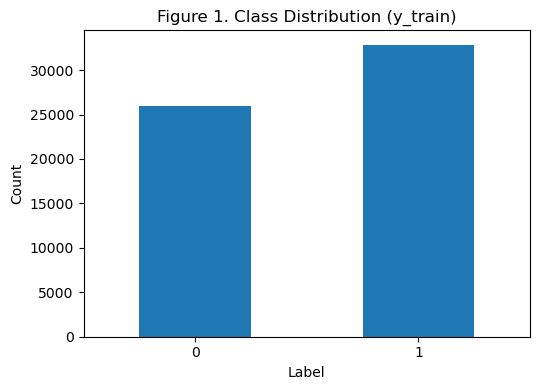

✅ Saved: fig1_class_distribution.png


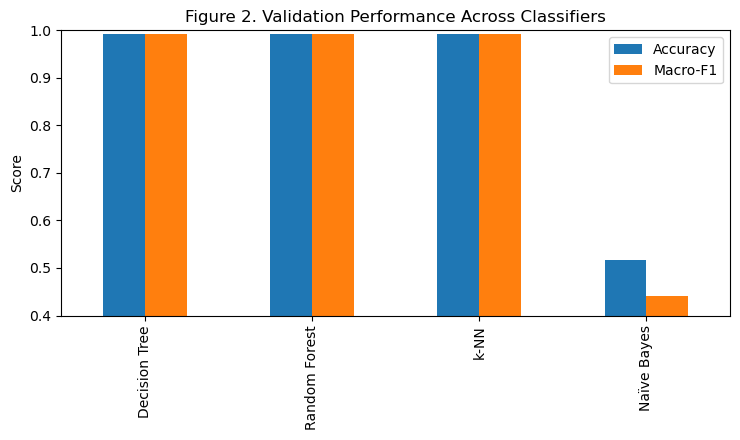

✅ Saved: fig2_validation_comparison.png


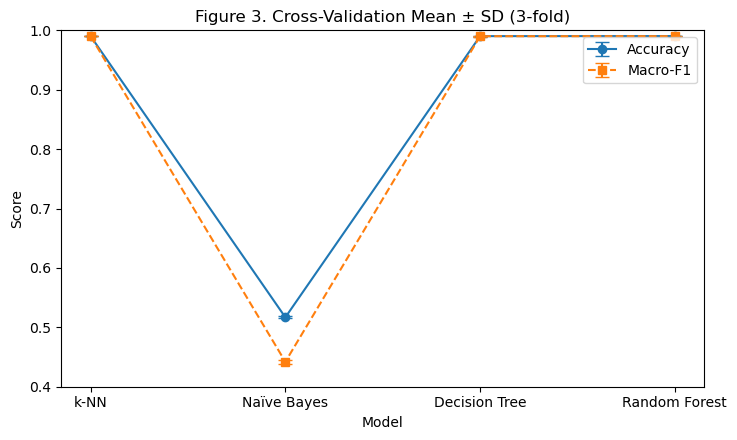

✅ Saved: fig3_cv_stability.png


<Figure size 550x450 with 0 Axes>

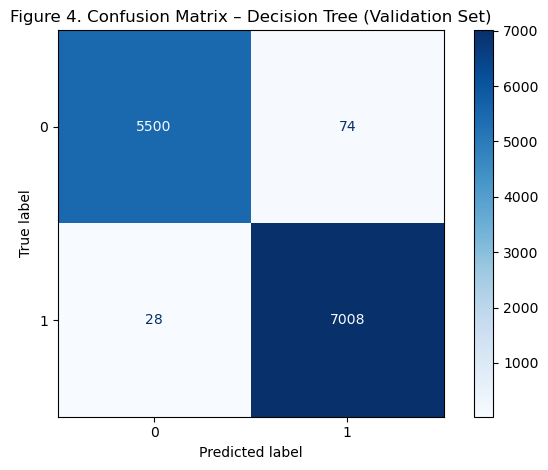

✅ Saved: fig4_confusion_matrix_dt.png


In [25]:
#Figures
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

def _save_show(fname, dpi=200):
    plt.tight_layout()
    plt.savefig(fname, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {fname}")

#Class distribution (train) 
labels = None
source = None
for name in ["y_train", "y", "y_val", "y_test"]:
    if name in globals():
        labels = globals()[name]
        source = name
        break

if labels is not None:
    plt.figure(figsize=(5.5, 4))
    pd.Series(labels).value_counts().sort_index().plot(kind='bar')
    plt.title(f'Figure 1. Class Distribution ({source})')
    plt.xlabel('Label'); plt.ylabel('Count')
    plt.xticks(rotation=0)
    _save_show('fig1_class_distribution.png')
else:
    print("Skipped Figure 1: no label vector in memory (run your Data Prep split cell).")

#Validation performance 
if 'compare_df' in globals() and {'Model','Val_Accuracy','Val_MacroF1'}.issubset(compare_df.columns):
    plt.figure(figsize=(7.5, 4.5))
    ax = compare_df.plot(
        x='Model', y=['Val_Accuracy', 'Val_MacroF1'],
        kind='bar', ax=plt.gca()
    )
    plt.title('Figure 2. Validation Performance Across Classifiers')
    plt.xlabel(''); plt.ylabel('Score')
    plt.ylim(0.4, 1.0)
    plt.legend(['Accuracy', 'Macro-F1'])
    _save_show('fig2_validation_comparison.png')
else:
    print("Skipped Figure 2: compare_df missing or missing required columns.")

#CV stability (mean ± SD) 
needed = {'Model','CV_Accuracy_mean','CV_Accuracy_sd','CV_MacroF1_mean','CV_MacroF1_sd'}
if 'cv_df' in globals() and needed.issubset(cv_df.columns):
    plt.figure(figsize=(7.5, 4.5))
    plt.errorbar(cv_df["Model"], cv_df["CV_Accuracy_mean"],
                 yerr=cv_df["CV_Accuracy_sd"], fmt='o-', capsize=5, label='Accuracy')
    plt.errorbar(cv_df["Model"], cv_df["CV_MacroF1_mean"],
                 yerr=cv_df["CV_MacroF1_sd"], fmt='s--', capsize=5, label='Macro-F1')
    plt.title('Figure 3. Cross-Validation Mean ± SD (3-fold)')
    plt.ylabel('Score'); plt.ylim(0.4, 1.0)
    plt.xlabel('Model'); plt.legend()
    _save_show('fig3_cv_stability.png')
else:
    print("Skipped Figure 3: cv_df missing or missing required columns.")

#Confusion matrix — Decision Tree on validation
if 'dt_model' in globals() and 'X_val' in globals() and 'y_val' in globals():
    plt.figure(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_estimator(
        dt_model, X_val, y_val,
        display_labels=['0', '1'],
        cmap='Blues',
        values_format='d'
    )
    plt.title('Figure 4. Confusion Matrix – Decision Tree (Validation Set)')
    _save_show('fig4_confusion_matrix_dt.png')
else:
    print("Skipped Figure 4: need dt_model, X_val, and y_val in memory.")
